<a href="https://colab.research.google.com/github/YuliaLoburets/A-B-test_project/blob/main/A_B_Testing_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
from google.colab import auth
auth.authenticate_user()
print('Authenticated successfully')

Authenticated successfully


In [43]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import matplotlib.ticker as ticker
warnings.filterwarnings('ignore')

In [44]:

# ── CONFIG ──────────────────────────────────────────────
PROJECT_ID = 'testproject-470912'
DATASET    = 'pricing_experiment.car_usage_data'
# ────────────────────────────────────────────────────────

client = bigquery.Client(project=PROJECT_ID)

# Plotting defaults
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})
PALETTE = ['#2563EB', '#16A34A', '#DC2626', '#D97706', '#7C3AED']

def run_query(sql):
    """Run a BigQuery SQL query and return a pandas DataFrame."""
    return client.query(sql).to_dataframe()

print('Setup complete')

Setup complete


In [45]:
desired_width=320
pd.set_option('display.width', desired_width)
pd.set_option('display.max_columns', 20)

In [46]:
overview_query = f"""
SELECT *
FROM `{DATASET}`
"""
overview = run_query(overview_query)
overview.head(10)

,rent_id,user_id,start_dt,end_dt,cost,type_,car_class,flag_ftr
0,7266017499955140000,6341823040309490000,48:26.0,26:57.0,-1250.0,Short rent,Comfort,0
1,2694397645716480000,7486465028761380000,03:01.0,39:21.0,0.0,Long rent,Comfort,1
2,3822972942289750000,8733503588685500000,02:09.0,40:36.0,0.0,Long rent,Comfort,1
3,16633516079053600,6696377725323650000,47:49.0,05:03.0,0.0,Long rent,Comfort,1
4,578314446309090000,6362516843803520000,56:10.0,03:06.0,0.0,Short rent,Comfort,1
5,3051109028683770000,7307266763897690000,30:47.0,24:34.0,0.0,Long rent,Comfort,1
6,8574504883423410000,9192171768180830000,43:48.0,50:42.0,0.0,Long rent,Comfort,-1
7,8764416851180600000,9089247902658340000,23:58.0,25:43.0,0.0,Long rent,Comfort,-1
8,9175531106799080000,5412519947454960000,08:43.0,42:16.0,0.0,Long rent,Comfort,1
9,8154826257376720000,3727813601910090000,28:06.0,09:57.0,0.0,Long rent,Comfort,-1


In [47]:
overview.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316469 entries, 0 to 316468
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   rent_id    316469 non-null  Int64  
 1   user_id    316469 non-null  Int64  
 2   start_dt   316469 non-null  object 
 3   end_dt     316469 non-null  object 
 4   cost       316469 non-null  float64
 5   type_      316469 non-null  object 
 6   car_class  316469 non-null  object 
 7   flag_ftr   316469 non-null  Int64  
dtypes: Int64(3), float64(1), object(4)
memory usage: 20.2+ MB


In [48]:
overview['cost'].describe()

,cost
count,316469.000000
mean,1663.399864
std,2302.953421
min,-1250.000000
25%,731.250000
50%,1239.583333
75%,1956.250000
max,425839.583300


In [49]:
dup = overview.groupby('user_id').agg(duplicates=('user_id','count')).reset_index()
dup.sort_values(by='duplicates', ascending=False)

,user_id,duplicates
6447,1615995789360480000,791
27832,6993220522717430000,367
35606,8998651449142730000,358
19082,4804034955114900000,319
7388,1845710661862130000,318
...,...,...
12208,3051291031027250000,1
12207,3051112852452310000,1
25,6314533619391700,1
14,2724197947325470,1


In [124]:
user_overview = overview.groupby('user_id').agg(
                                                rentals=('rent_id', 'count'),
                                                total_revenue = ('cost', 'sum'),
                                                median_revenue = ('cost', 'median'),
                                                mean_revenue = ('cost', 'mean'),
                                                max_revenue = ('cost', 'max'),
                                                min_revenue = ('cost','min')).round(1).reset_index()
user_overview.sort_values(by='rentals', ascending=False).head()

,user_id,rentals,total_revenue,median_revenue,mean_revenue,max_revenue,min_revenue
6447,1615995789360480000,791,41989.6,31.2,53.1,433.3,0.0
27832,6993220522717430000,367,298393.8,785.4,813.1,3266.7,39.6
35606,8998651449142730000,358,105414.6,155.2,294.5,1420.8,-308.3
19082,4804034955114900000,319,273183.3,658.3,856.4,6843.8,0.0
7388,1845710661862130000,318,212731.2,85.4,669.0,25908.3,0.0


In [51]:
user_overview.drop(columns=['user_id']).describe()

,rentals,total_revenue,median_revenue,mean_revenue,max_revenue,min_revenue
count,36484.0,3.648400e+04,36484.000000,36484.000000,36484.000000,36484.000000
mean,8.674186,1.442864e+04,1595.555811,1744.385013,3214.898616,982.643364
std,15.086891,2.981754e+04,1784.914532,2068.292185,4800.842231,1613.071858
min,1.0,-5.229000e+02,-261.500000,-261.500000,-206.200000,-1250.000000
25%,1.0,2.008300e+03,866.700000,969.600000,1350.000000,314.600000
50%,3.0,5.450000e+03,1293.800000,1408.300000,2216.700000,658.300000
75%,9.0,1.521880e+04,1856.200000,2008.300000,3673.425000,1204.200000
max,791.0,1.889585e+06,93770.800000,157874.300000,425839.600000,93770.800000


In [52]:
round(overview.query('cost <=0').shape[0]/overview.shape[0]*100,1)

2.4

Only 2.4% of transactions have non-positive values. The presence of zero and negative transactions suggests promotional activities, refunds, cancellations, or accounting adjustments. Since their business meaning is not documented and the share is relatively small, they were retained in the exploratory analysis and flagged as a potential area for further business validation

## Overall revenue and rental distribution

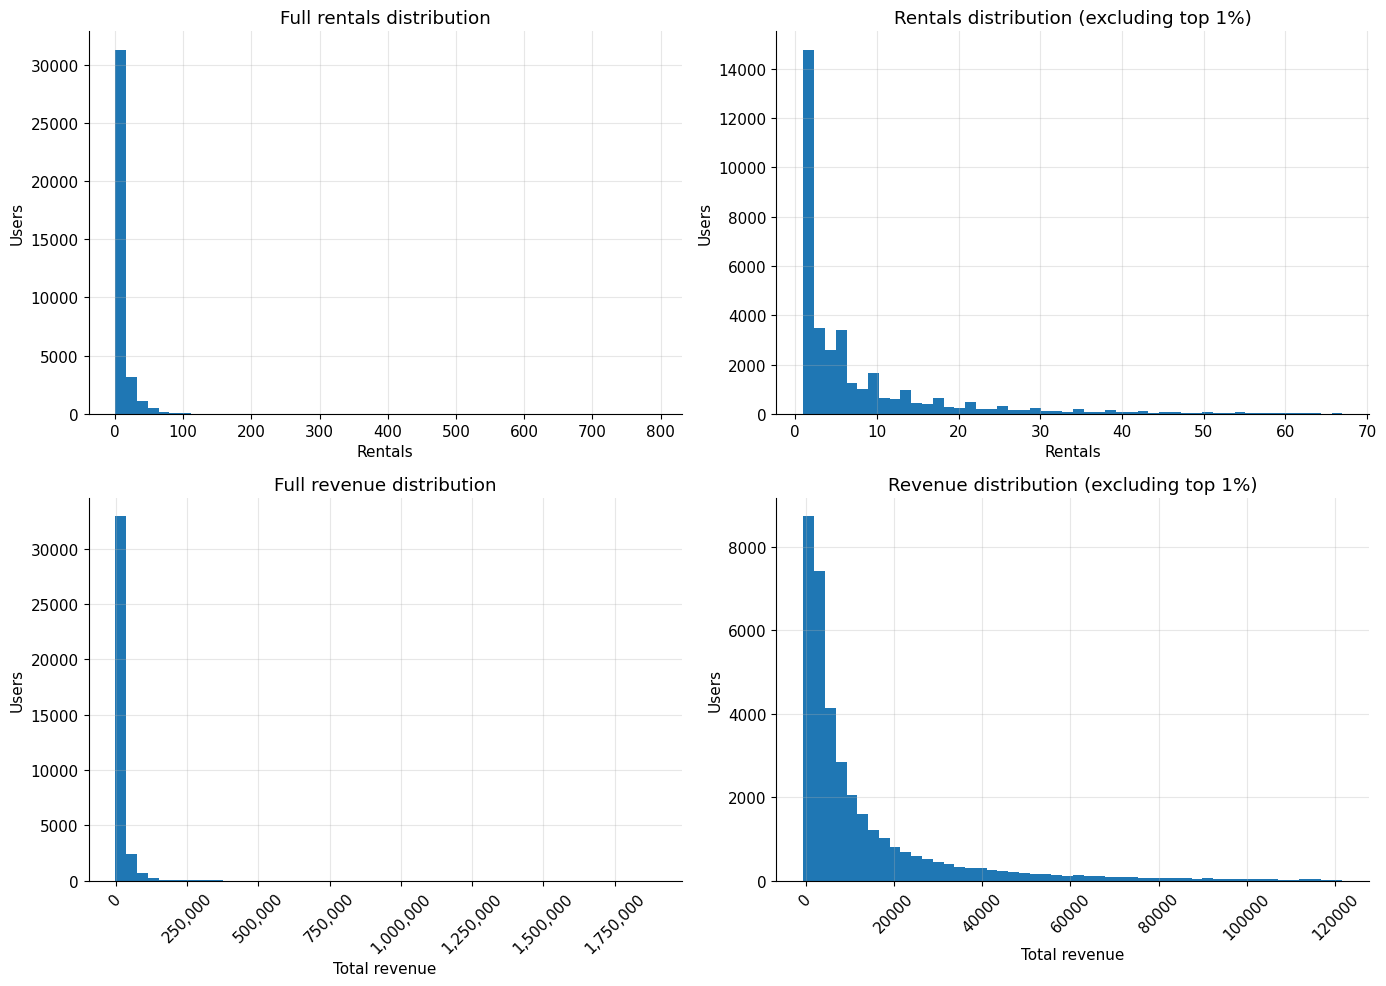

In [53]:
plt.close('all')
q99_rentals = user_overview['rentals'].quantile(0.99)
rentals_less_q99 = user_overview.query('rentals < @q99_rentals')

q99_costs = user_overview['total_revenue'].quantile(0.99)
cost_less_q99 =  user_overview.query('total_revenue < @q99_costs')

fig, axes = plt.subplots(2,2, figsize=(14,10))
axes[0,0].hist(user_overview['rentals'], bins=50)
axes[0,0].set_title('Full rentals distribution')
axes[0,0].set_xlabel('Rentals')
axes[0,0].set_ylabel('Users')

axes[0,1].hist(rentals_less_q99['rentals'], bins=50)
axes[0,1].set_title('Rentals distribution (excluding top 1%)')
axes[0,1].set_xlabel('Rentals')
axes[0,1].set_ylabel('Users')

axes[1,0].hist(user_overview['total_revenue'], bins=50)
axes[1,0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].set_title('Full revenue distribution')
axes[1,0].set_xlabel('Total revenue')
axes[1,0].set_ylabel('Users')

axes[1,1].hist(cost_less_q99['total_revenue'], bins=50)
axes[1,1].set_title('Revenue distribution (excluding top 1%)')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].set_xlabel('Total revenue')
axes[1,1].set_ylabel('Users')

plt.tight_layout()
plt.show()

Both rental frequency and total spending are highly right-skewed. Most users have a small number of rentals and relatively low total spend, while a small group of highly active users generates disproportionately high activity and revenue. Therefore, customer segmentation by usage frequency and spending level is necessary before designing a pricing experiment.

In [109]:
#building the lorenz curve to see the revenue distribution among users
lorenz=user_overview.query('total_revenue>0')[['user_id','total_revenue']].sort_values('total_revenue').reset_index(drop=True)
lorenz['cum_users'] = (lorenz.index+1)/len(lorenz)
lorenz['cum_revenue'] = lorenz['total_revenue'].cumsum()/lorenz['total_revenue'].sum()

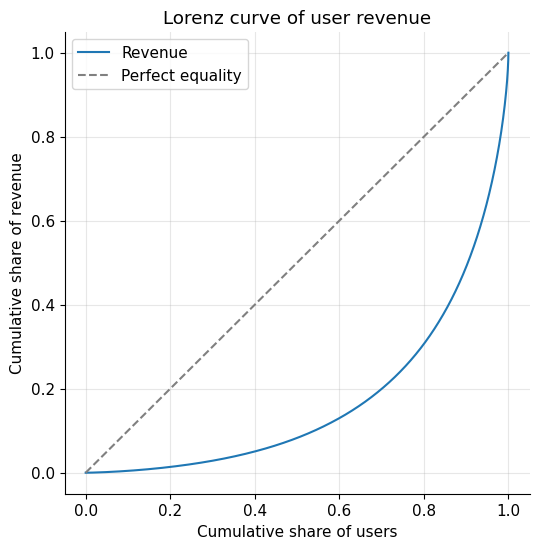

In [110]:
plt.figure(figsize=(6,6))

plt.plot(
    lorenz['cum_users'],
    lorenz['cum_revenue'],
    label='Revenue'
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='gray',
    label='Perfect equality'
)

plt.xlabel('Cumulative share of users')
plt.ylabel('Cumulative share of revenue')
plt.title('Lorenz curve of user revenue')
plt.legend()

plt.show()

In [100]:
top_users = user_overview[['user_id','total_revenue']].sort_values('total_revenue', ascending=False).reset_index(drop=True)
top_users['cum_revenue'] = top_users['total_revenue'].cumsum() / top_users['total_revenue'].sum()

In [102]:
percentiles = [0.01, 0.05, 0.10, 0.20]

for p in percentiles:
    revenue_share = (
        top_users
        .head(int(len(top_users) * p))
        ['total_revenue']
        .sum()
        / top_users['total_revenue'].sum()
        * 100
    )

    print(f'Top {p:.0%} users generate {revenue_share:.1f}% of revenue')

Top 1% users generate 13.8% of revenue
Top 5% users generate 35.9% of revenue
Top 10% users generate 51.6% of revenue
Top 20% users generate 70.0% of revenue


The Lorenz Curve shows  a highly unequal revenue distribution across the users. Revenue is concentrated among a relatively small group of customers, indicating that the platform relies heavily on its most valuable users.

The cumulative revenue analysis shows that:

*   the top 1% of users generate 13.8% of total revenue;
*   the top 5% generate 35.9%;
*   the top 10% generate 51.6%;
*   the top 20% account for 70.0% of total revenue.


##Customer Segmentation Analysis

In [54]:
user_overview[['total_revenue', 'rentals']].quantile([0.1,0.5,0.75,0.95])

,total_revenue,rentals
0.10,877.10,1.0
0.50,5450.00,3.0
0.75,15218.80,9.0
0.95,57453.53,35.0


In [55]:
user_overview['frequency_segment'] = pd.cut(user_overview['rentals'], bins=[0, 3, 9, 35, np.inf], labels = ['Low', 'Medium', 'High','Power Users'])
user_overview['revenue_segment'] = pd.cut(user_overview['total_revenue'], bins=[-np.inf, 5450, 15218.8, 57453.5, np.inf], labels = ['Low', 'Medium', 'High','Power Users'])

In [103]:
frequency_segment = user_overview.groupby('frequency_segment').agg(
                                               avg_rentals=('rentals','mean'),
                                               total_rentals = ('rentals','sum'),
                                               users = ('user_id','count'),
                                               total_revenue = ('total_revenue','sum'),
                                               median_revenue_per_user = ('total_revenue','median'),
                                               average_revenue_per_user = ('total_revenue','mean')).round(1)
frequency_segment['average_revenue_per_rental'] = round(frequency_segment['total_revenue']/frequency_segment['total_rentals'],1)
frequency_segment['revenue_prct_of_total'] = round(frequency_segment['total_revenue']/overview['cost'].sum()*100,1).map('{:.1f}%'.format)
frequency_segment['rentals_prct_of_total'] = round(frequency_segment['total_rentals']/frequency_segment['total_rentals'].sum()*100,1).map('{:.1f}%'.format)
frequency_segment['users_prct_of_total'] = round(frequency_segment['users']/frequency_segment['users'].sum()*100,1).map('{:.1f}%'.format)
frequency_segment

,avg_rentals,total_rentals,users,total_revenue,median_revenue_per_user,average_revenue_per_user,average_revenue_per_rental,revenue_prct_of_total,rentals_prct_of_total,users_prct_of_total
frequency_segment,,,,,,,,,,
Low,1.7,30691,18284,54992456.4,2064.6,3007.7,1791.8,10.4%,9.7%,50.1%
Medium,5.9,53861,9174,92142336.3,8258.3,10043.9,1710.7,17.5%,17.0%,25.1%
High,17.9,130720,7292,216670278.4,24479.2,29713.4,1657.5,41.2%,41.3%,20.0%
Power Users,58.4,101197,1734,162609420.4,75302.1,93777.1,1606.9,30.9%,32.0%,4.8%


In [104]:
revenue_segment = user_overview.groupby('revenue_segment').agg(
                                          avg_rentals=('rentals','mean'),
                                          total_rentals = ('rentals','sum'),
                                          users = ('user_id','count'),
                                          total_revenue = ('total_revenue','sum'),
                                          median_revenue_per_user = ('total_revenue','median'),
                                          average_revenue_per_user = ('total_revenue','mean')
                                          ).round(1)
revenue_segment['average_revenue_per_rental'] = round(revenue_segment['total_revenue']/revenue_segment['total_rentals'],1)
revenue_segment['revenue_prct_of_total'] = round(revenue_segment['total_revenue']/overview['cost'].sum()*100,1).map('{:.1f}%'.format)
revenue_segment['rentals_prct_of_total'] = round(revenue_segment['total_rentals']/revenue_segment['total_rentals'].sum()*100,1).map('{:.1f}%'.format)
revenue_segment['users_prct_of_total'] = round(revenue_segment['users']/revenue_segment['users'].sum()*100,1).map('{:.1f}%'.format)
revenue_segment

,avg_rentals,total_rentals,users,total_revenue,median_revenue_per_user,average_revenue_per_user,average_revenue_per_rental,revenue_prct_of_total,rentals_prct_of_total,users_prct_of_total
revenue_segment,,,,,,,,,,
Low,2.0,36575,18243,41137501.1,2008.3,2255.0,1124.7,7.8%,11.6%,50.0%
Medium,6.2,56306,9121,85403004.7,8906.2,9363.3,1516.8,16.2%,17.8%,25.0%
High,17.9,130625,7295,210848302.0,25814.6,28903.1,1614.1,40.1%,41.3%,20.0%
Power Users,50.9,92963,1825,189025683.7,82389.6,103575.7,2033.3,35.9%,29.4%,5.0%


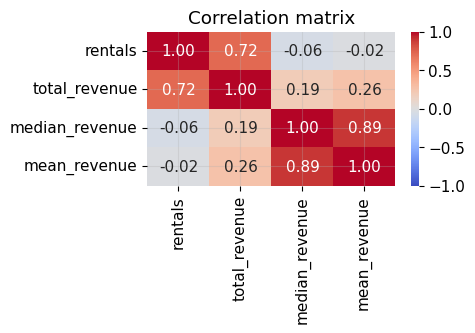

In [58]:
corr = user_overview[['rentals','total_revenue','median_revenue','mean_revenue']].corr()
plt.figure(figsize =(4,2))
sns.heatmap(corr, annot=True, cmap='coolwarm',  fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation matrix')
plt.show()

In [59]:
round(pd.crosstab(user_overview['frequency_segment'], user_overview['revenue_segment'], normalize='index')*100,1).map('{:.1f}%'.format)

revenue_segment,Low,Medium,High,Power Users
frequency_segment,,,,
Low,87.5%,11.4%,1.1%,0.0%
Medium,24.0%,61.4%,14.2%,0.4%
High,0.7%,19.2%,72.8%,7.3%
Power Users,0.0%,0.1%,27.7%,72.3%


**Customer Segmentation Insights**



Customer value is highly concentrated among a relatively small group of users. Although **Low-frequency** users account for **50%** of the customer base, they generate only **10.4%** of total revenue. In contrast, **High-frequency** users and **Power Users** represent only **24.8**% of all users but contribute **72.1%** of the platform's total revenue.

A similar pattern is observed when users are segmented by revenue. The top **25%** of customers **(High + Power Users)** generate approximately **76%** of total revenue, highlighting a strong concentration of revenue among the platform's most valuable customers.

The correlation analysis further supports these findings. Rental frequency has a strong positive correlation (r = 0.72) with total customer revenue, indicating that users who rent more frequently generate substantially higher lifetime revenue. In contrast, rental frequency shows almost no correlation with average or median revenue per rental, suggesting that higher customer value is driven primarily by more frequent rentals rather than higher spending per individual rental.

The cross-segmentation analysis confirms this relationship. Most users remain within the same value tier regardless of whether they are segmented by rental frequency or historical revenue. For example, **87.5% of Low-frequency users** also belong to the **Low-revenue** segment, while **72.8%** of High-frequency users and **72.3%** of Power Users fall into the corresponding High- and Power-revenue segments. This consistency demonstrates that rental frequency is a reliable proxy for customer value.

Since a relatively small group of users generates the majority of the platform's revenue, simple random assignment may result in an uneven distribution of high-value customers between experimental groups. Therefore, the A/B experiment should incorporate stratified randomization based on historical rental frequency or historical revenue to ensure balanced control and treatment groups.

##Car class and rental type analysis

In [61]:
car_stats = overview.groupby('car_class').agg(rentals=('rent_id','count'), users=('user_id','nunique'),total_revenue=('cost','sum'),mean_revenue=('cost','mean'), median_revenue=('cost','median')).round(1)
car_stats['rentals_prct'] =  round(car_stats['rentals']/car_stats['rentals'].sum()*100,1).map('{:.1f}%'.format)
car_stats['users_prct'] =  round(car_stats['users']/car_stats['users'].sum()*100,1).map('{:.1f}%'.format)
car_stats['revenuet_prct'] =  round(car_stats['total_revenue']/car_stats['total_revenue'].sum()*100,1).map('{:.1f}%'.format)
car_stats

,rentals,users,total_revenue,mean_revenue,median_revenue,rentals_prct,users_prct,revenuet_prct
car_class,,,,,,,,
Comfort,40718,14878,94895904.2,2330.6,1572.9,12.9%,30.3%,18.0%
Econom,275751,34273,431518587.5,1564.9,1202.1,87.1%,69.7%,82.0%


In [62]:
# the key indicators for rent type
rent_type_stats = overview.groupby('type_').agg(rentals=('rent_id','count'), users=('user_id','nunique'),total_revenue=('cost','sum'),mean_revenue=('cost','mean'), median_revenue=('cost','median')).round(1)
rent_type_stats['rentals_prct'] =  round(rent_type_stats['rentals']/rent_type_stats['rentals'].sum()*100,1).map('{:.1f}%'.format)
rent_type_stats['users_prct'] =  round(rent_type_stats['users']/rent_type_stats['users'].sum()*100,1).map('{:.1f}%'.format)
rent_type_stats['revenue_prct'] =  round(rent_type_stats['total_revenue']/rent_type_stats['total_revenue'].sum()*100,1).map('{:.1f}%'.format)
rent_type_stats

,rentals,users,total_revenue,mean_revenue,median_revenue,rentals_prct,users_prct,revenue_prct
type_,,,,,,,,
Long rent,4706,2461,4102279.2,871.7,0.0,1.5%,6.4%,0.8%
Short rent,311763,35954,522312212.5,1675.4,1254.2,98.5%,93.6%,99.2%


In [63]:
overview.query("type_ == 'Long rent'")['cost'].describe()

,cost
count,4706.000000
mean,871.712530
std,7596.791216
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,425839.583300


In [ ]:
#identify the proportion of records with zero cost values in the long rents
overview[(overview['type_']=='Long rent') & (overview['cost']==0)].shape[0]/overview[(overview['type_']=='Long rent')].shape[0]*100

95.70760730981725

**Car class analysis**

Approximately **70%** of users rented **Economy** cars, while **30%** used the **Comfort class**. Economy is the dominant product, accounting for **87.1** % of all rentals and generating **82%** of total revenue. **Comfort** represents only **12.9%** of rentals, but contributes **18%** of total revenue, indicating a higher average rental value.

As expected, the median rental cost for **Comfort (1,573)** is higher than for **Economy (1,202)**, although the difference is moderate rather than substantial. This suggests that customer price sensitivity may differ across vehicle classes, therefore car class should be considered as a stratification factor in the pricing experiment or analyzed separately during the experiment evaluation.

**Rental type analysis**

The analysis revealed that **95.7%** of **Long rent** transactions have a recorded cost equal to zero. Without additional business context, it is impossible to determine whether these observations represent promotional rentals, complimentary extensions, technical records, or another business process. Consequently, the true contribution of **Long rent** to pricing behaviour cannot be reliably assessed from the available data.

Moreover, **Long rent** represents only **1.5%** of all rentals, **6.4%** of users, and contributes just **0.8%** of total revenue, indicating that it is a niche product within the dataset.

Given both the uncertainty surrounding zero-cost transactions and the very small sample size, I would exclude **Long rent** from the primary A/B pricing experiment and focus the analysis on **Short rent**, which accounts for nearly all rentals **(98.5%)** and revenue **(99.2%)**.

In [139]:
user_car_type = (
                  overview
                  .groupby('user_id')['car_class']
                  .agg(lambda x: set(x))
                  .reset_index()
)

def classify(classes):
    if classes == {'Econom'}:
        return 'Econom only'
    elif classes == {'Comfort'}:
        return 'Comfort only'
    else:
        return 'Mixed'

user_car_type['user_segment'] = user_car_type['car_class'].apply(classify)

(
    user_car_type['user_segment']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .map('{:.1f}%'.format)
)

,proportion
user_segment,
Econom only,59.2%
Mixed,34.7%
Comfort only,6.1%


In [140]:
user_car_type = user_car_type.merge(
    user_overview[['user_id', 'total_revenue']],
    how='left',
    on='user_id'
)

In [141]:
user_car_type.groupby('user_segment').agg(
    users=('user_id', 'nunique'),
    total_revenue=('total_revenue', 'sum'),
    median_revenue=('total_revenue', 'median'),
    mean_revenue=('total_revenue', 'mean')
).round(1)

,users,total_revenue,median_revenue,mean_revenue
user_segment,,,,
Comfort only,2211,8891993.8,2050.0,4021.7
Econom only,21606,168392276.3,3264.6,7793.8
Mixed,12667,349130221.4,14877.1,27562.2


Users were additionally segmented based on their car class usage patterns: Econom only, Comfort only, and Mixed. The majority of users rented only Economy cars (59.2%), while 34.7% used both Economy and Comfort, and only 6.1% rented Comfort exclusively. Mixed users showed the highest customer value, with a median revenue of 14.9k compared to 3.3k for Economy-only users and 2.1k for Comfort-only users. This suggests that users who switch between vehicle classes are significantly more engaged and valuable. For the pricing experiment, this group should be monitored separately, as their ability to choose between car classes may make them more flexible or sensitive to relative price changes between Economy and Comfort.

##  Flag_ftr data exploration

In [ ]:
flag_ftr_overview = overview.groupby('flag_ftr').agg(rentals=('rent_id','count'), users=('user_id','nunique'),total_revenue=('cost','sum'),mean_revenue=('cost','mean'), median_revenue=('cost','median')).round(1)
flag_ftr_overview['rentals_prct'] =  round(flag_ftr_overview['rentals']/flag_ftr_overview['rentals'].sum()*100,1).map('{:.1f}%'.format)
flag_ftr_overview['users_prct'] =  round(flag_ftr_overview['users']/flag_ftr_overview['users'].sum()*100,1).map('{:.1f}%'.format)
flag_ftr_overview['revenue_prct'] =  round(flag_ftr_overview['total_revenue']/flag_ftr_overview['total_revenue'].sum()*100,1).map('{:.1f}%'.format)

flag_ftr_overview

,rentals,users,total_revenue,mean_revenue,median_revenue,rentals_prct,users_prct,revenue_prct
flag_ftr,,,,,,,,
-1,1026,683,0.0,0.0,0.0,0.3%,1.7%,0.0%
0,6283,6283,12111929.2,1927.7,1220.8,2.0%,15.3%,2.3%
1,309160,34097,514302562.5,1663.5,1243.8,97.7%,83.0%,97.7%


In [ ]:
round(overview.groupby('flag_ftr')['car_class'].value_counts(normalize=True)*100,1)

flag_ftr  car_class
-1        Econom       73.2
          Comfort      26.8
0         Econom       84.7
          Comfort      15.3
1         Econom       87.2
          Comfort      12.8
Name: proportion, dtype: float64

In [ ]:
round(overview.groupby('flag_ftr')['type_'].value_counts(normalize=True)*100,1)

flag_ftr  type_     
-1        Long rent     63.3
          Short rent    36.7
0         Short rent    99.8
          Long rent      0.2
1         Short rent    98.7
          Long rent      1.3
Name: proportion, dtype: float64

The business meaning of flag_ftr cannot be determined from the available data. Although the name may suggest a feature or free-trial flag, the observed distributions do not provide sufficient evidence to support this assumption. Records with flag_ftr = 0 account for only 2% of all rentals and have revenue statistics comparable to those with flag_ftr = 1, indicating no meaningful difference in transaction value. In contrast, all records with flag_ftr = -1 have zero revenue and are predominantly associated with Long Rent transactions, suggesting that this value likely represents a separate non-revenue business scenario. Without additional business documentation, no further assumptions about the purpose of this field were made, and it was not used in the experiment design.